# Смотрим ещё раз: что считает строка

Первый семинар (`look_at_data.ipynb`) идёт по отбору признаков и кодировкам.
Здесь другой вопрос: **что такое одна строка** в выгрузке Директа и какую метрику
на ней можно честно считать.

Данные те же: `dataset/bycicles.csv`, магазин велосипедов Centra Market.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from great_tables import GT
from IPython.display import display

sns.set_theme(style="whitegrid")


def show_table(df, title, subtitle=None):
    """Печатает таблицу с названием. Годится и для Series, и для groupby."""
    out = df.to_frame(name=df.name or "значение") if isinstance(df, pd.Series) else df.copy()
    if not (isinstance(out.index, pd.RangeIndex) and out.index.name is None):
        out = out.reset_index()
    for col in out.columns:
        if pd.api.types.is_datetime64_any_dtype(out[col]):
            out[col] = pd.to_datetime(out[col]).dt.strftime("%Y-%m-%d")
        elif str(out[col].dtype).startswith("period"):
            out[col] = out[col].astype(str)
    tbl = GT(out)
    tbl = tbl.tab_header(title=title, subtitle=subtitle) if subtitle else tbl.tab_header(title=title)
    display(tbl)


DATA_PATH = "../dataset/bycicles.csv"
data = pd.read_csv(DATA_PATH)
data["Дата"] = pd.to_datetime(data["Дата"], format="%d.%m.%Y")
print(data.shape)
print("даты:", data["Дата"].min().date(), "—", data["Дата"].max().date(), ",", data["Дата"].nunique(), "дней")
show_table(data.head(3), "Первые строки выгрузки")


(9923, 28)
даты: 2023-06-15 — 2024-06-14 , 95 дней


GT(_tbl_data=         Дата             Группа    № Группы  № Объявления Тип площадки  \
0  2023-06-15  Велосипед Stinger  4296804875  M-9591380676        поиск   
1  2023-06-15  Велосипед Stinger  4296804875  M-9591380678        поиск   
2  2023-06-15  Велосипед Женский  4296804877  M-9591380694        поиск   

        Формат Размер изображения Тип устройства           Пол  \
0    текстовый    без изображения      мобильные  не определен   
1  графический     с изображением        десктоп       мужской   
2  графический     с изображением        десктоп       женский   

                Категория таргетинга  ... Клики CTR (%) wCTR (%)  \
0                    Целевые запросы  ...     0     0.0      0.0   
1  Запросы с упоминанием конкурентов  ...     0     0.0      0.0   
2                    Целевые запросы  ...     0     0.0      0.0   

  Расход (руб.) Конверсия (%)/Товар добавлен в корзину  \
0           0.0                                      -   
1           0.0                                      -   
2           0.0                                      -   

   Конверсия (%)/Заказ оформлен  Конверсия (%)/Лид с Centra Market//Динамика  \
0                             -                                            -   
1                             -                                            -   
2                             -                                            -   

   Конверсии/Товар добавлен в корзину  Конверсии/Заказ оформлен  \
0                                   -                         -   
1                                   -                         -   
2                                   -                         -   

   Конверсии/Лид с Centra Market//Динамика  
0                                        -  
1                                        -  
2                                        -  

[3 rows x 28 columns], _body=<great_tables._gt_data.Body object at 0x17664e610>, _boxhead=Boxhead([ColInfo(var='Дата', type=<ColInfoTypeEnum.default: 1>, column_label='Дата', column_align='right', column_width=None), ColInfo(var='Группа', type=<ColInfoTypeEnum.default: 1>, column_label='Группа', column_align='left', column_width=None), ColInfo(var='№ Группы', type=<ColInfoTypeEnum.default: 1>, column_label='№ Группы', column_align='right', column_width=None), ColInfo(var='№ Объявления', type=<ColInfoTypeEnum.default: 1>, column_label='№ Объявления', column_align='left', column_width=None), ColInfo(var='Тип площадки', type=<ColInfoTypeEnum.default: 1>, column_label='Тип площадки', column_align='left', column_width=None), ColInfo(var='Формат', type=<ColInfoTypeEnum.default: 1>, column_label='Формат', column_align='left', column_width=None), ColInfo(var='Размер изображения', type=<ColInfoTypeEnum.default: 1>, column_label='Размер изображения', column_align='left', column_width=None), ColInfo(var='Тип устройства', type=<ColInfoTypeEnum.default: 1>, column_label='Тип устройства', column_align='left', column_width=None), ColInfo(var='Пол', type=<ColInfoTypeEnum.default: 1>, column_label='Пол', column_align='left', column_width=None), ColInfo(var='Категория таргетинга', type=<ColInfoTypeEnum.default: 1>, column_label='Категория таргетинга', column_align='left', column_width=None), ColInfo(var='Упоминание брендов', type=<ColInfoTypeEnum.default: 1>, column_label='Упоминание брендов', column_align='left', column_width=None), ColInfo(var='Уровень платежеспособности', type=<ColInfoTypeEnum.default: 1>, column_label='Уровень платежеспособности', column_align='left', column_width=None), ColInfo(var='Возраст', type=<ColInfoTypeEnum.default: 1>, column_label='Возраст', column_align='left', column_width=None), ColInfo(var='Заголовок', type=<ColInfoTypeEnum.default: 1>, column_label='Заголовок', column_align='left', column_width=None), ColInfo(var='Текст', type=<ColInfoTypeEnum.default: 1>, column_label='Текст', column_align='left', column_width=None), ColInfo(var='Ссылка', type=<ColInfoTypeEnum.default: 1>, column_label='С

### Что такое одна строка

Одна клетка отчёта Директа: «вот это объявление, в этот день, у людей с таким набором пометок — сколько раз показали, сколько кликнули, сколько списали».

Это не человек и не объявление целиком. Ниже — как одна группа выглядит внутри дня и как та же группа выглядит в разные дни.


#### Одна группа в течение дня

Группа «Велосипед Купить», 1 мая 2024. Это четыре объявления
и десятки срезов по устройству, полу, возрасту, запросу и упоминанию бренда.

Если сложить показы и клики по всем этим строкам — получится день группы.
Каждая строка сама по себе часто один показ и CTR 0% или 100%.


In [2]:
GROUP = "Велосипед Купить"
DAY = pd.Timestamp("2024-05-01")

one_day = data[(data["Группа"] == GROUP) & (data["Дата"] == DAY)].copy()
print(
    f"{GROUP}, {DAY.date()}: "
    f"{len(one_day)} строк, "
    f"{one_day['№ Объявления'].nunique()} объявления, "
    f"{one_day['Показы'].sum()} показов, "
    f"{one_day['Клики'].sum()} кликов, "
    f"CTR дня {100 * one_day['Клики'].sum() / one_day['Показы'].sum():.1f}%"
)

by_ad = (
    one_day.groupby(["№ Объявления", "Заголовок"], dropna=False)
    .agg(строк=("Показы", "size"), показы=("Показы", "sum"), клики=("Клики", "sum"))
    .assign(CTR=lambda x: 100 * x["клики"] / x["показы"])
)
show_table(by_ad.round(1), "Объявления группы за день", f"{GROUP}, {DAY.date()}")

slice_cols = [
    "№ Объявления",
    "Формат",
    "Тип устройства",
    "Пол",
    "Возраст",
    "Категория таргетинга",
    "Упоминание брендов",
    "Показы",
    "Клики",
    "CTR (%)",
]
# одно объявление внутри группы — чтобы было видно, на что режется день
ad = one_day["№ Объявления"].value_counts().idxmax()
one_ad = one_day.loc[one_day["№ Объявления"] == ad, slice_cols].sort_values(
    ["Тип устройства", "Пол", "Возраст"]
)
show_table(one_ad, f"Срезы объявления {ad}", f"{len(one_ad)} строк внутри того же дня")


Велосипед Купить, 2024-05-01: 50 строк, 4 объявления, 73 показов, 12 кликов, CTR дня 16.4%


GT(_tbl_data=   № Объявления                 Заголовок  строк  показы  клики   CTR
0  M-9591380816       Магазин велосипедов     32      53      9  17.0
1  M-9591380818  {PHRASEКупить велосипед}      6       7      1  14.3
2  M-9591380820          Купить велосипед     10      11      1   9.1
3  M-9591380822          Купить велосипед      2       2      1  50.0, _body=<great_tables._gt_data.Body object at 0x107f50d90>, _boxhead=Boxhead([ColInfo(var='№ Объявления', type=<ColInfoTypeEnum.default: 1>, column_label='№ Объявления', column_align='left', column_width=None), ColInfo(var='Заголовок', type=<ColInfoTypeEnum.default: 1>, column_label='Заголовок', column_align='left', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='показы', type=<ColInfoTypeEnum.default: 1>, column_label='показы', column_align='right', column_width=None), ColInfo(var='клики', type=<ColInfoTypeEnum.default: 1>, column_label='клики', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1766718d0>, _spanners=Spanners([]), _heading=Heading(title='Объявления группы за день', subtitle='Велосипед Купить, 2024-05-01', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x176672950>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x176672a10>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1766728d0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='ta

GT(_tbl_data=    index  № Объявления       Формат Тип устройства           Пол  \
0    6013  M-9591380816  графический        десктоп       женский   
1    6011  M-9591380816  графический        десктоп       мужской   
2    6012  M-9591380816  графический        десктоп       мужской   
3    6009  M-9591380816  графический        десктоп  не определен   
4    6010  M-9591380816  графический        десктоп  не определен   
5    6032  M-9591380816    текстовый      мобильные       женский   
6    6033  M-9591380816    текстовый      мобильные       женский   
7    6038  M-9591380816    текстовый      мобильные       женский   
8    6039  M-9591380816    текстовый      мобильные       женский   
9    6040  M-9591380816    текстовый      мобильные       женский   
10   6034  M-9591380816    текстовый      мобильные       женский   
11   6035  M-9591380816    текстовый      мобильные       женский   
12   6037  M-9591380816    текстовый      мобильные       женский   
13   6031  M-9591380816    текстовый      мобильные       женский   
14   6036  M-9591380816    текстовый      мобильные       женский   
15   6016  M-9591380816    текстовый      мобильные       мужской   
16   6022  M-9591380816    текстовый      мобильные       мужской   
17   6027  M-9591380816    текстовый      мобильные       мужской   
18   6017  M-9591380816    текстовый      мобильные       мужской   
19   6020  M-9591380816    текстовый      мобильные       мужской   
20   6023  M-9591380816    текстовый      мобильные       мужской   
21   6018  M-9591380816    текстовый      мобильные       мужской   
22   6021  M-9591380816    текстовый      мобильные       мужской   
23   6024  M-9591380816    текстовый      мобильные       мужской   
24   6028  M-9591380816    текстовый      мобильные       мужской   
25   6019  M-9591380816    текстовый      мобильные       мужской   
26   6029  M-9591380816    текстовый      мобильные       мужской   
27   6015  M-9591380816    текстовый      мобильные       мужской   
28   6026  M-9591380816    текстовый      мобильные       мужской   
29   6014  M-9591380816    текстовый      мобильные       мужской   
30   6025  M-9591380816    текстовый      мобильные       мужской   
31   6030  M-9591380816    текстовый      мобильные       мужской   

         Возраст    Категория таргетинга                 Упоминание брендов  \
0      старше 55         Целевые запросы       Без упоминания вашего бренда   
1          35-44         Целевые запросы       Без упоминания вашего бренда   
2          35-44         Целевые запросы  С упоминанием брендов конкурентов   
3   не определен         Целевые запросы       Без упоминания вашего бренда   
4   не определен  Альтернативные запросы  С упоминанием брендов конкурентов   
5          18-24         Целевые запросы       Без упоминания вашего бренда   
6          25-34         Целевые запросы       Без упоминания вашего бренда   
7          25-34         Целевые запросы  С упоминанием брендов конкурентов   
8          25-34           Узкие запросы       Без упоминания вашего бренда   
9          25-34           Узкие запросы       Без упоминания вашего бренда   
10         35-44         Целевые запросы       Без упоминания вашего бренда   
11         45-54         Целевые запросы       Без упоминания вашего бренда   
12         45-54         Целевые запросы       Без упоминания вашего бренда   
13     младше 18         Целевые запросы       Без упоминания вашего бренда   
14     старше 55         Целевые запросы       Без упоминания вашего бренда   
15         18-24         Целевые запросы       Без упоминания вашего бренда   
16         18-24         Целевые запросы  С упоминанием брендов конкурентов   
17         18-24           Узкие запросы       Без упоминания вашего бренда   
18         25-34         Целевые запросы       Без упоминания вашего бренда   
19         25-34         Целевые запросы       Без упоминания вашего бренда   
20         25-34         Целевые запросы  С упомин

#### Та же группа в разные дни

«Велосипед Купить» живёт почти все 95 дней выгрузки. Число строк скачет,
потому что Директ по-разному нарезает аудиторию — это не то же самое, что объём.

15 июня 2023: 30 строк, 54 показа, 3 клика, CTR дня 5.6%.
1 мая 2024: 50 строк, 73 показа, 12 кликов, CTR дня 16.4%.
Объявлений в оба дня четыре. По строкам май «в полтора раза больше»,
по кликам — в четыре.


GT(_tbl_data=         Дата  строк  показы  клики  объявлений   CTR
0  2023-06-15     30      54      3           4   5.6
1  2024-05-01     50      73     12           4  16.4, _body=<great_tables._gt_data.Body object at 0x176658d90>, _boxhead=Boxhead([ColInfo(var='Дата', type=<ColInfoTypeEnum.default: 1>, column_label='Дата', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='показы', type=<ColInfoTypeEnum.default: 1>, column_label='показы', column_align='right', column_width=None), ColInfo(var='клики', type=<ColInfoTypeEnum.default: 1>, column_label='клики', column_align='right', column_width=None), ColInfo(var='объявлений', type=<ColInfoTypeEnum.default: 1>, column_label='объявлений', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x176671e90>, _spanners=Spanners([]), _heading=Heading(title='Одна группа в два разных дня', subtitle='Велосипед Купить', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x176684b50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x176687390>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x176686d90>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', 

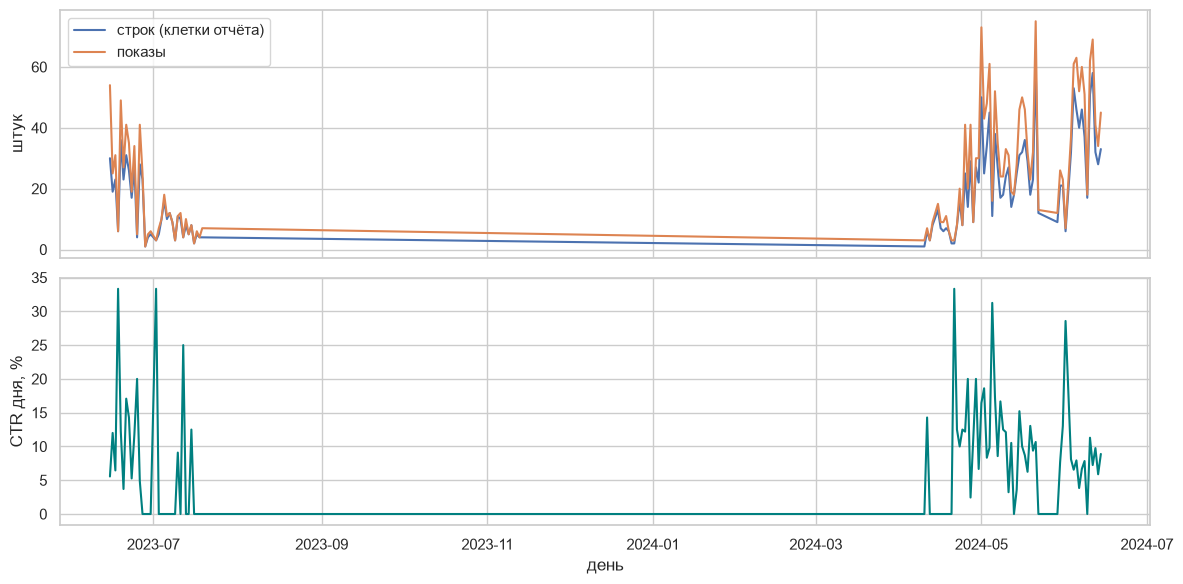

In [3]:
by_day = (
    data[data["Группа"] == GROUP]
    .groupby("Дата")
    .agg(
        строк=("Показы", "size"),
        показы=("Показы", "sum"),
        клики=("Клики", "sum"),
        объявлений=("№ Объявления", "nunique"),
    )
)
by_day["CTR"] = 100 * by_day["клики"] / by_day["показы"]

compare_days = [pd.Timestamp("2023-06-15"), pd.Timestamp("2024-05-01")]
show_table(
    by_day.loc[compare_days].round(1),
    "Одна группа в два разных дня",
    GROUP,
)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(by_day.index, by_day["строк"], label="строк (клетки отчёта)")
axes[0].plot(by_day.index, by_day["показы"], label="показы")
axes[0].legend()
axes[0].set_ylabel("штук")
axes[1].plot(by_day.index, by_day["CTR"], color="teal")
axes[1].set_ylabel("CTR дня, %")
axes[1].set_xlabel("день")
plt.tight_layout()
plt.show()


In [4]:
show_table(data["Показы"].value_counts().sort_index().head(8), "Сколько показов бывает в одной строке")
show_table(data["Клики"].value_counts().sort_index(), "Сколько кликов бывает в одной строке")
print(
    "строк с 1 показом: "
    f"{(data['Показы'] == 1).mean():.1%}; "
    f"строк без клика: {(data['Клики'] == 0).mean():.1%}"
)


GT(_tbl_data=   Показы  count
0       0      1
1       1   8069
2       2   1286
3       3    335
4       4    116
5       5     66
6       6     24
7       7      8, _body=<great_tables._gt_data.Body object at 0x17666b010>, _boxhead=Boxhead([ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1766705d0>, _spanners=Spanners([]), _heading=Heading(title='Сколько показов бывает в одной строке', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1766a0f90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x17666a990>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x17666a310>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(scss=True, category='heading', type='value', value='center'), heading_title_font_size=OptionsInfo(scss=True, category='heading', type='px', value='125%'), heading_title_font_w

GT(_tbl_data=   Клики  count
0      0   8603
1      1   1262
2      2     47
3      3      9
4      4      2, _body=<great_tables._gt_data.Body object at 0x176669710>, _boxhead=Boxhead([ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x176672910>, _spanners=Spanners([]), _heading=Heading(title='Сколько кликов бывает в одной строке', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x17666ac10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x17666b810>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x176669610>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(scss=True, category='heading', type='value', value='center'), heading_title_font_size=OptionsInfo(scss=True, category='heading', type='px', value='125%'), heading_title_font_weight=OptionsInfo(scss=True, category='heading', type='value

строк с 1 показом: 81.3%; строк без клика: 86.7%


### Прочерки и подписи «не определено»

Пустое здесь редко бывает `NaN`. Чаще это прочерк в конверсиях
или подпись «не определен» / «не определено» / «Остальные».
`info()` такое не подсветит.


In [5]:
missing_labels = ["-", "не определен", "не определено"]
rows = []
for col in data.columns:
    if data[col].dtype == "object":
        share = data[col].isin(missing_labels).mean()
    else:
        share = data[col].isna().mean()
    nunique = data[col].nunique(dropna=True)
    rows.append((col, nunique, share))

overview = pd.DataFrame(rows, columns=["колонка", "уникальных", "доля пустого"])
show_table(
    overview.sort_values("доля пустого", ascending=False).assign(**{"доля пустого": lambda x: (100 * x["доля пустого"]).round(1)}),
    "Пустые значения и подписи «не определено»",
    "доля в процентах",
)


GT(_tbl_data=    index                                      колонка  уникальных  \
0      15                                       Ссылка           0   
1       0                                         Дата          95   
2       1                                       Группа          25   
3      26                     Конверсии/Заказ оформлен           1   
4      25           Конверсии/Товар добавлен в корзину           2   
5      24  Конверсия (%)/Лид с Centra Market//Динамика           2   
6      23                 Конверсия (%)/Заказ оформлен           1   
7      22       Конверсия (%)/Товар добавлен в корзину           4   
8      21                                Расход (руб.)        1203   
9      20                                     wCTR (%)         993   
10     19                                      CTR (%)          20   
11     18                                        Клики           5   
12     17                            Взвешенные показы         430   
13     16                                       Показы          15   
14     14                                        Текст          37   
15     13                                    Заголовок          64   
16     12                                      Возраст           7   
17     11                   Уровень платежеспособности           4   
18     10                           Упоминание брендов           4   
19      9                         Категория таргетинга           7   
20      8                                          Пол           3   
21      7                               Тип устройства           3   
22      6                           Размер изображения           2   
23      5                                       Формат           2   
24      4                                 Тип площадки           1   
25      3                                 № Объявления          81   
26      2                                     № Группы          25   
27     27      Конверсии/Лид с Centra Market//Динамика           2   

    доля пустого  
0          100.0  
1            0.0  
2            0.0  
3            0.0  
4            0.0  
5            0.0  
6            0.0  
7            0.0  
8            0.0  
9            0.0  
10           0.0  
11           0.0  
12           0.0  
13           0.0  
14           0.0  
15           0.0  
16           0.0  
17           0.0  
18           0.0  
19           0.0  
20           0.0  
21           0.0  
22           0.0  
23           0.0  
24           0.0  
25           0.0  
26           0.0  
27           0.0  , _body=<great_tables._gt_data.Body object at 0x176771790>, _boxhead=Boxhead([ColInfo(var='index', type=<ColInfoTypeEnum.default: 1>, column_label='index', column_align='right', column_width=None), ColInfo(var='колонка', type=<ColInfoTypeEnum.default: 1>, column_label='колонка', column_align='left', column_width=None), ColInfo(var='уникальных', type=<ColInfoTypeEnum.default: 1>, column_label='уникальных', column_align='right', column_width=None), ColInfo(var='доля пустого', type=<ColInfoTypeEnum.default: 1>, column_label='доля пустого', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x176743590>, _spanners=Spanners([]), _heading=Heading(title='Пустые значения и подписи «не определено»', subtitle='доля в процентах', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x176750f90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x176772150>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x176771e10>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category

In [6]:
# Заказы в этой выгрузке не случились ни разу.
# Корзина и лид есть, но это десятки строк на десять тысяч.
conv = {
    "корзина": "Конверсии/Товар добавлен в корзину",
    "заказ": "Конверсии/Заказ оформлен",
    "лид": "Конверсии/Лид с Centra Market//Динамика",
}
for name, col in conv.items():
    n = (data[col].astype(str) != "-").sum()
    print(f"{name}: {n} строк")


корзина: 22 строк
заказ: 0 строк
лид: 8 строк


### CTR строки и CTR сегмента

`CTR (%)` в таблице — клики / показы **внутри среза**.
При одном показе это 0% или 100%. На всей таблице таких строк ~96%.

Доля кликов, о которой можно говорить вслух:

$$
\mathrm{CTR} = \frac{\sum \text{клики}}{\sum \text{показы}}
$$


In [7]:
row_ctr = data["CTR (%)"]
print(f"CTR в строке = 0%:   {(row_ctr == 0).mean():.1%}")
print(f"CTR в строке = 100%: {(row_ctr == 100).mean():.1%}")
print(f"средний CTR по строкам: {row_ctr.mean():.1f}%")
print(f"CTR по сумме кликов и показов: {100 * data['Клики'].sum() / data['Показы'].sum():.1f}%")
print(f"максимум wCTR: {data['wCTR (%)'].max():.0f}%  — взвешенные показы бывают меньше кликов")


CTR в строке = 0%:   86.7%
CTR в строке = 100%: 9.2%
средний CTR по строкам: 11.0%
CTR по сумме кликов и показов: 10.9%
максимум wCTR: 1927%  — взвешенные показы бывают меньше кликов


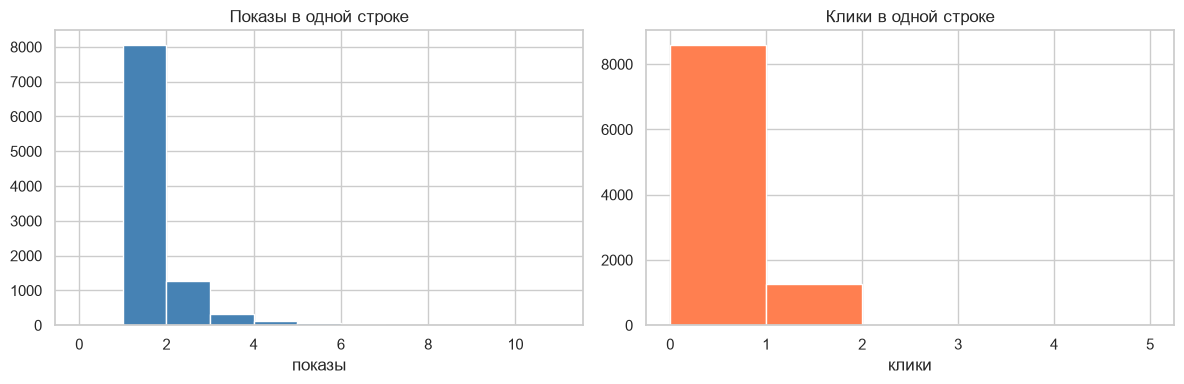

In [8]:
def segment_ctr(df, by):
    g = df.groupby(by, dropna=False)[["Показы", "Клики", "Расход (руб.)"]].sum()
    g["строк"] = df.groupby(by, dropna=False).size()
    g["CTR"] = 100 * g["Клики"] / g["Показы"]
    return g.sort_values("Показы", ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data["Показы"], bins=range(0, 12), color="steelblue", edgecolor="white")
axes[0].set_title("Показы в одной строке")
axes[0].set_xlabel("показы")
axes[1].hist(data["Клики"], bins=range(0, 6), color="coral", edgecolor="white")
axes[1].set_title("Клики в одной строке")
axes[1].set_xlabel("клики")
plt.tight_layout()
plt.show()


### Доли кликов по срезам — не countplot

Ниже в каждом сегменте одна и та же тройка: сколько строк, сколько показов, какая доля кликов.
Если смотреть только на число строк, детские велосипеды и «младше 18» выглядят иначе, чем по показам.


In [9]:
show_table(segment_ctr(data, "Пол").round(1), "CTR по полу", "сумма кликов / сумма показов, не среднее по строкам")
show_table(segment_ctr(data, "Возраст").round(1), "CTR по возрасту")
show_table(segment_ctr(data, "Категория таргетинга").round(1), "CTR по категории таргетинга")
show_table(segment_ctr(data, "Тип устройства").round(1), "CTR по типу устройства")


GT(_tbl_data=            Пол  Показы  Клики  Расход (руб.)  строк   CTR
0       мужской    8268    948        34194.0   6294  11.5
1       женский    4291    420        15079.9   3403   9.8
2  не определен     257     23          731.6    226   8.9, _body=<great_tables._gt_data.Body object at 0x1767ec150>, _boxhead=Boxhead([ColInfo(var='Пол', type=<ColInfoTypeEnum.default: 1>, column_label='Пол', column_align='left', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x176673990>, _spanners=Spanners([]), _heading=Heading(title='CTR по полу', subtitle='сумма кликов / сумма показов, не среднее по строкам', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x176658f90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x176743690>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x176740990>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', va

GT(_tbl_data=        Возраст  Показы  Клики  Расход (руб.)  строк   CTR
0         35-44    4332    497        18880.2   3186  11.5
1         25-34    3459    376        14868.3   2595  10.9
2         45-54    1766    205         7469.1   1417  11.6
3         18-24    1136    117         3943.6    934  10.3
4     старше 55     930    105         2918.8    796  11.3
5     младше 18     732     40          695.3    606   5.5
6  не определен     461     51         1230.2    389  11.1, _body=<great_tables._gt_data.Body object at 0x176771a90>, _boxhead=Boxhead([ColInfo(var='Возраст', type=<ColInfoTypeEnum.default: 1>, column_label='Возраст', column_align='left', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x176769390>, _spanners=Spanners([]), _heading=Heading(title='CTR по возрасту', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x177960c50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x177960510>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x177963fd0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='

GT(_tbl_data=                Категория таргетинга  Показы  Клики  Расход (руб.)  строк  \
0                    Целевые запросы    9020   1130        41403.5   6650   
1                      Узкие запросы    2054    179         5216.3   1670   
2                      не определено     891     25          451.6    826   
3  Запросы с упоминанием конкурентов     336     26         1476.5    305   
4             Альтернативные запросы     291     18          850.3    263   
5                    Широкие запросы     212     13          607.3    197   
6              Сопутствующие запросы      12      0            0.0     12   

    CTR  
0  12.5  
1   8.7  
2   2.8  
3   7.7  
4   6.2  
5   6.1  
6   0.0  , _body=<great_tables._gt_data.Body object at 0x1767ec150>, _boxhead=Boxhead([ColInfo(var='Категория таргетинга', type=<ColInfoTypeEnum.default: 1>, column_label='Категория таргетинга', column_align='left', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x177960c50>, _spanners=Spanners([]), _heading=Heading(title='CTR по категории таргетинга', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x176772510>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x176772f50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x176773250>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_b

GT(_tbl_data=  Тип устройства  Показы  Клики  Расход (руб.)  строк   CTR
0      мобильные    9771   1001        37418.6   7368  10.2
1        десктоп    2840    367        11967.3   2367  12.9
2       планшеты     205     23          619.5    188  11.2, _body=<great_tables._gt_data.Body object at 0x176763fd0>, _boxhead=Boxhead([ColInfo(var='Тип устройства', type=<ColInfoTypeEnum.default: 1>, column_label='Тип устройства', column_align='left', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x107f52110>, _spanners=Spanners([]), _heading=Heading(title='CTR по типу устройства', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1766a0f90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1767a1510>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1767a0410>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8

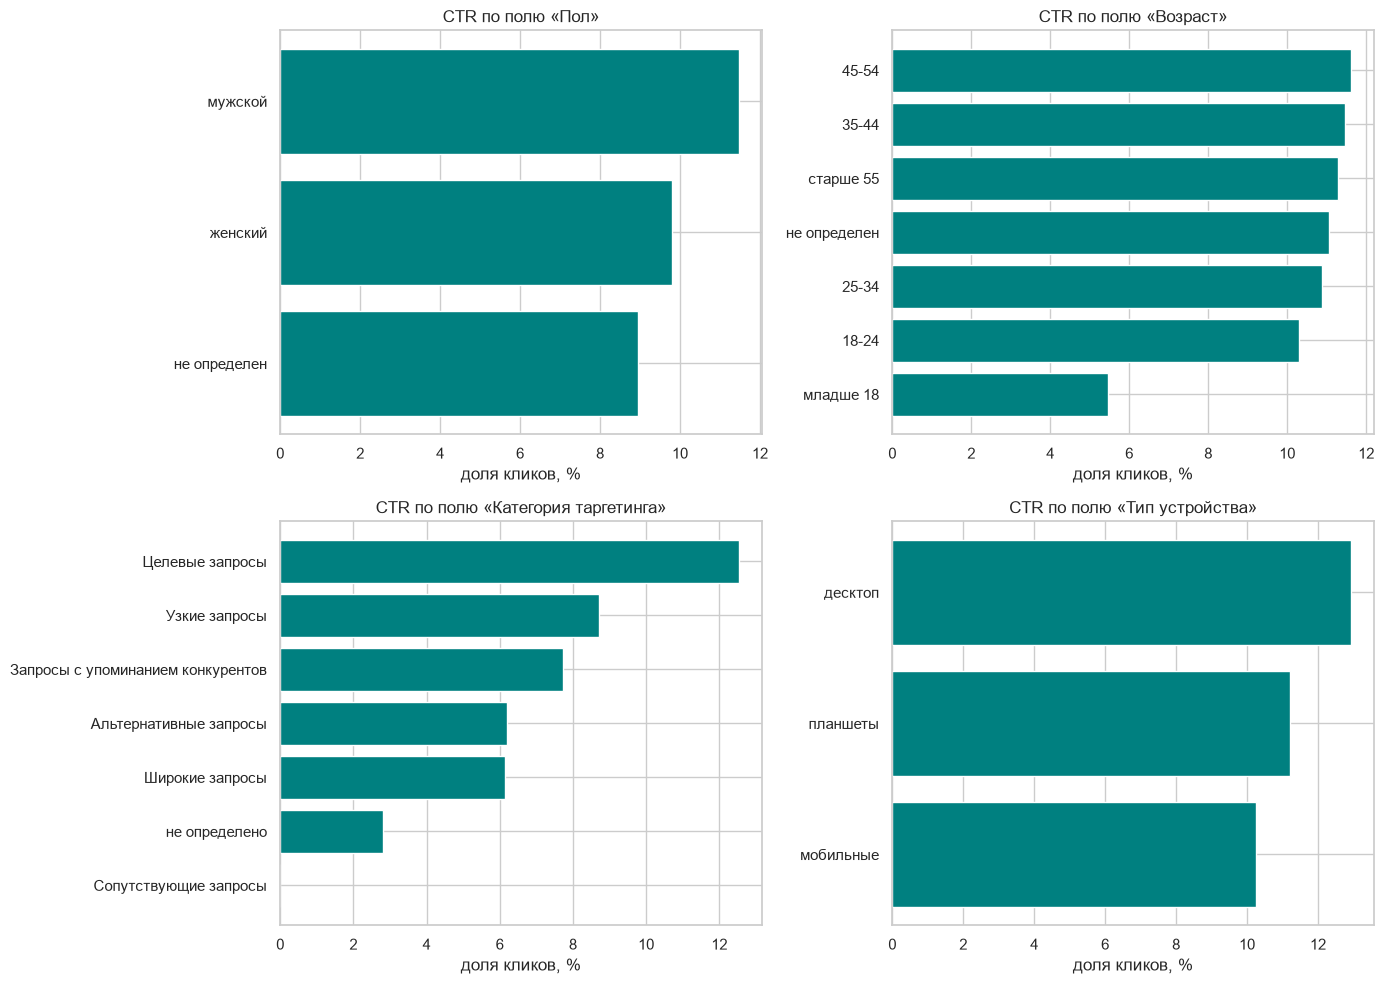

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

slices = [
    (axes[0, 0], "Пол"),
    (axes[0, 1], "Возраст"),
    (axes[1, 0], "Категория таргетинга"),
    (axes[1, 1], "Тип устройства"),
]
for ax, col in slices:
    tab = segment_ctr(data, col).sort_values("CTR")
    ax.barh(tab.index.astype(str), tab["CTR"], color="teal")
    ax.set_title(f"CTR по полю «{col}»")
    ax.set_xlabel("доля кликов, %")

plt.tight_layout()
plt.show()


In [11]:
group_tab = segment_ctr(data, "Группа")
show_table(group_tab.head(8).round(1), "Группы с наибольшим числом показов")
show_table(
    group_tab[group_tab["Показы"] >= 200].sort_values("CTR", ascending=False).head(8).round(1),
    "Высокий CTR при ≥ 200 показах",
)


GT(_tbl_data=                   Группа  Показы  Клики  Расход (руб.)  строк   CTR
0        Велосипед Купить    2314    211         6827.2   1796   9.1
1       Велосипед Иркутск    1809    195         7733.6   1428  10.8
2         Велосипед Stels    1520    144         6055.2   1070   9.5
3             Веломагазин    1167    131         5187.2    914  11.2
4       Велосипед Каталог    1049     88         4565.6    653   8.4
5       Велосипед Ангарск     800    118         3428.9    610  14.8
6  Велосипед Подростковый     732     91         3533.0    526  12.4
7     Велик Купить / Цена     621     55         1827.6    512   8.9, _body=<great_tables._gt_data.Body object at 0x107f36e90>, _boxhead=Boxhead([ColInfo(var='Группа', type=<ColInfoTypeEnum.default: 1>, column_label='Группа', column_align='left', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x177ae1890>, _spanners=Spanners([]), _heading=Heading(title='Группы с наибольшим числом показов', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1766a0f90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1779f3850>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1779f3910>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_

GT(_tbl_data=                    Группа  Показы  Клики  Расход (руб.)  строк   CTR
0        Велосипед Детский     375     83         2779.8    292  22.1
1         Велосипед Братск     361     63         1823.6    319  17.5
2  Велосипед +для лет/года     215     33         1137.0    190  15.3
3        Велосипед Stinger     323     48         1297.3    284  14.9
4        Велосипед Ангарск     800    118         3428.9    610  14.8
5   Велосипед Подростковый     732     91         3533.0    526  12.4
6              Веломагазин    1167    131         5187.2    914  11.2
7        Велосипед Иркутск    1809    195         7733.6   1428  10.8, _body=<great_tables._gt_data.Body object at 0x177a28190>, _boxhead=Boxhead([ColInfo(var='Группа', type=<ColInfoTypeEnum.default: 1>, column_label='Группа', column_align='left', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1779a3650>, _spanners=Spanners([]), _heading=Heading(title='Высокий CTR при ≥ 200 показах', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1779d93d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1779daf50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1779dabd0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), ta

### Время

В таблице два куска: лето 2023 и весна 2024. Для велосипедов это не фон,
а сезон. Ряд ниже — сумма по дню, не среднее CTR по строкам.


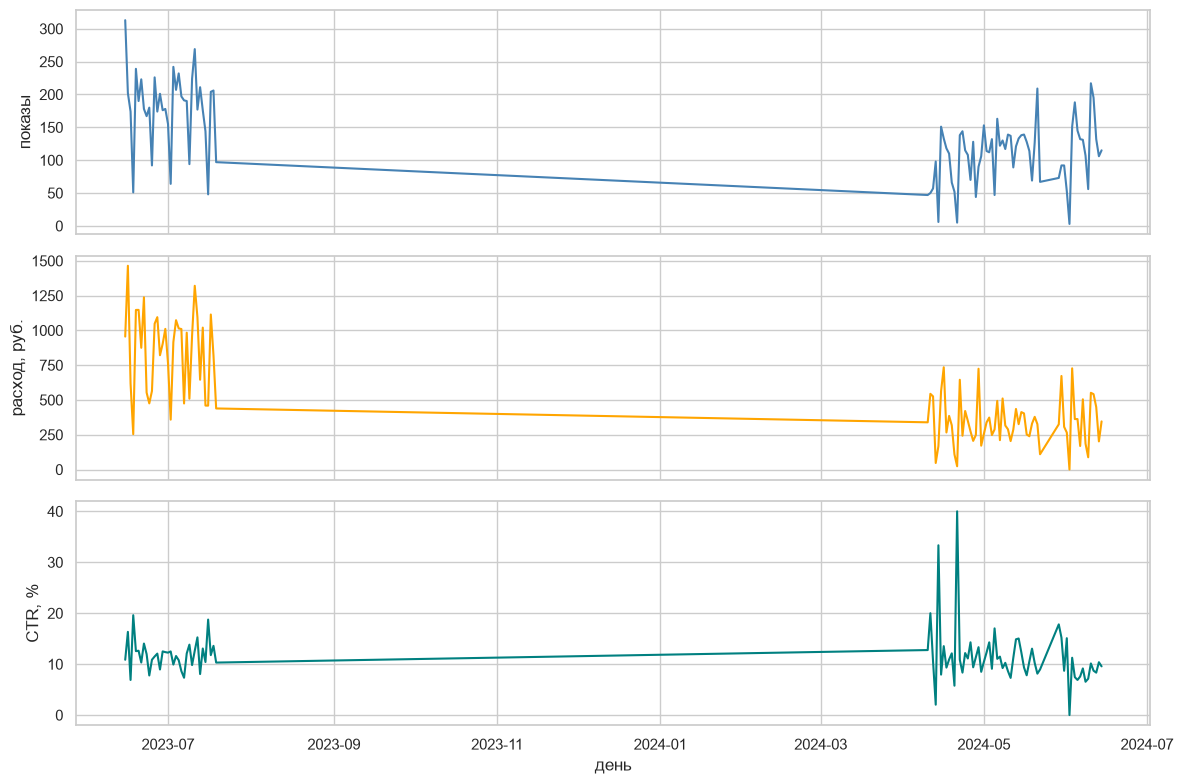

GT(_tbl_data=          Дата  Показы  Клики  Расход (руб.)    CTR
0   2023-06-30    2964    344       14170.99  11.61
1   2023-07-31    3328    376       15439.72  11.30
2   2023-08-31       0      0           0.00    NaN
3   2023-09-30       0      0           0.00    NaN
4   2023-10-31       0      0           0.00    NaN
5   2023-11-30       0      0           0.00    NaN
6   2023-12-31       0      0           0.00    NaN
7   2024-01-31       0      0           0.00    NaN
8   2024-02-29       0      0           0.00    NaN
9   2024-03-31       0      0           0.00    NaN
10  2024-04-30    1836    193        7306.02  10.51
11  2024-05-31    2957    324        8332.81  10.96
12  2024-06-30    1731    154        4755.93   8.90, _body=<great_tables._gt_data.Body object at 0x1767ecd10>, _boxhead=Boxhead([ColInfo(var='Дата', type=<ColInfoTypeEnum.default: 1>, column_label='Дата', column_align='right', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x177c43050>, _spanners=Spanners([]), _heading=Heading(title='Показы, клики и CTR по месяцам', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x177bca750>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x177bc8a90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x177bc8310>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_includ

In [12]:
daily = (
    data.groupby("Дата")[["Показы", "Клики", "Расход (руб.)"]]
    .sum()
    .sort_index()
)
daily["CTR"] = 100 * daily["Клики"] / daily["Показы"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(daily.index, daily["Показы"], color="steelblue")
axes[0].set_ylabel("показы")
axes[1].plot(daily.index, daily["Расход (руб.)"], color="orange")
axes[1].set_ylabel("расход, руб.")
axes[2].plot(daily.index, daily["CTR"], color="teal")
axes[2].set_ylabel("CTR, %")
axes[2].set_xlabel("день")
plt.tight_layout()
plt.show()

monthly = (
    daily.resample("ME")[["Показы", "Клики", "Расход (руб.)"]]
    .sum()
    .assign(CTR=lambda x: 100 * x["Клики"] / x["Показы"])
    .round(2)
)
show_table(monthly, "Показы, клики и CTR по месяцам")


### Две колонки про одно и то же

Формат объявления и «размер изображения» режут таблицу одинаково:
текстовый = без картинки, графический = с картинкой.
В модель достаточно одной из них.


In [13]:
show_table(
    pd.crosstab(data["Формат"], data["Размер изображения"]),
    "Формат и картинка — одна и та же нарезка",
)
print("площадка:", data["Тип площадки"].unique())
print("ссылка заполнена:", data["Ссылка"].notna().sum(), "из", len(data))


GT(_tbl_data=Размер изображения       Формат  без изображения  с изображением
0                   графический                0            2918
1                     текстовый             7005               0, _body=<great_tables._gt_data.Body object at 0x1779ac550>, _boxhead=Boxhead([ColInfo(var='Формат', type=<ColInfoTypeEnum.default: 1>, column_label='Формат', column_align='left', column_width=None), ColInfo(var='без изображения', type=<ColInfoTypeEnum.default: 1>, column_label='без изображения', column_align='right', column_width=None), ColInfo(var='с изображением', type=<ColInfoTypeEnum.default: 1>, column_label='с изображением', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1779f3250>, _spanners=Spanners([]), _heading=Heading(title='Формат и картинка — одна и та же нарезка', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x177ab5950>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1767ec410>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1767ecd10>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None),

площадка: <StringArray>
['поиск']
Length: 1, dtype: str
ссылка заполнена: 0 из 9923


### Текст объявления — без NLP

В заголовке часто шаблон `{PHRASE…}`. В тексте часто цена.
Этого хватает, чтобы спросить: кликают ли иначе по шаблону и по объявлению с ценой.


In [14]:
text = data.assign(
    шаблон=data["Заголовок"].str.contains("PHRASE", na=False),
    цена_в_тексте=data["Текст"].str.contains(r"\d", na=False),
)
print("доля строк с {PHRASE}:", f"{text['шаблон'].mean():.1%}")
print("доля строк с цифрой в тексте:", f"{text['цена_в_тексте'].mean():.1%}")
show_table(segment_ctr(text, "шаблон").round(1), "CTR: заголовок с {PHRASE} и без")
show_table(segment_ctr(text, "цена_в_тексте").round(1), "CTR: есть ли цифра в тексте объявления")
print("уникальных заголовков:", data["Заголовок"].nunique(), ", текстов:", data["Текст"].nunique())


доля строк с {PHRASE}: 32.3%
доля строк с цифрой в тексте: 76.1%


GT(_tbl_data=   шаблон  Показы  Клики  Расход (руб.)  строк   CTR
0   False    8781    935        33504.2   6721  10.6
1    True    4035    456        16501.3   3202  11.3, _body=<great_tables._gt_data.Body object at 0x177acea50>, _boxhead=Boxhead([ColInfo(var='шаблон', type=<ColInfoTypeEnum.default: 1>, column_label='шаблон', column_align='center', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x177b8ec90>, _spanners=Spanners([]), _heading=Heading(title='CTR: заголовок с {PHRASE} и без', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x177caba50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x177ca8a50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x177cab650>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', val

GT(_tbl_data=   цена_в_тексте  Показы  Клики  Расход (руб.)  строк   CTR
0           True    9860   1047        37622.1   7556  10.6
1          False    2956    344        12383.4   2367  11.6, _body=<great_tables._gt_data.Body object at 0x177b4cb90>, _boxhead=Boxhead([ColInfo(var='цена_в_тексте', type=<ColInfoTypeEnum.default: 1>, column_label='цена_в_тексте', column_align='center', column_width=None), ColInfo(var='Показы', type=<ColInfoTypeEnum.default: 1>, column_label='Показы', column_align='right', column_width=None), ColInfo(var='Клики', type=<ColInfoTypeEnum.default: 1>, column_label='Клики', column_align='right', column_width=None), ColInfo(var='Расход (руб.)', type=<ColInfoTypeEnum.default: 1>, column_label='Расход (руб.)', column_align='right', column_width=None), ColInfo(var='строк', type=<ColInfoTypeEnum.default: 1>, column_label='строк', column_align='right', column_width=None), ColInfo(var='CTR', type=<ColInfoTypeEnum.default: 1>, column_label='CTR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x177b4edd0>, _spanners=Spanners([]), _heading=Heading(title='CTR: есть ли цифра в тексте объявления', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x177ca8890>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x177ca88d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x177caa110>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss

уникальных заголовков: 64 , текстов: 37


### Корреляции: сто строк одного дня и вся таблица

В первом семинаре pairplot и VIF считаются на первых 100 строках.
Это почти один день. Пары «что выкинуть» на всём файле другие:
взвешенные показы уже не копия показов, wCTR почти сам по себе.


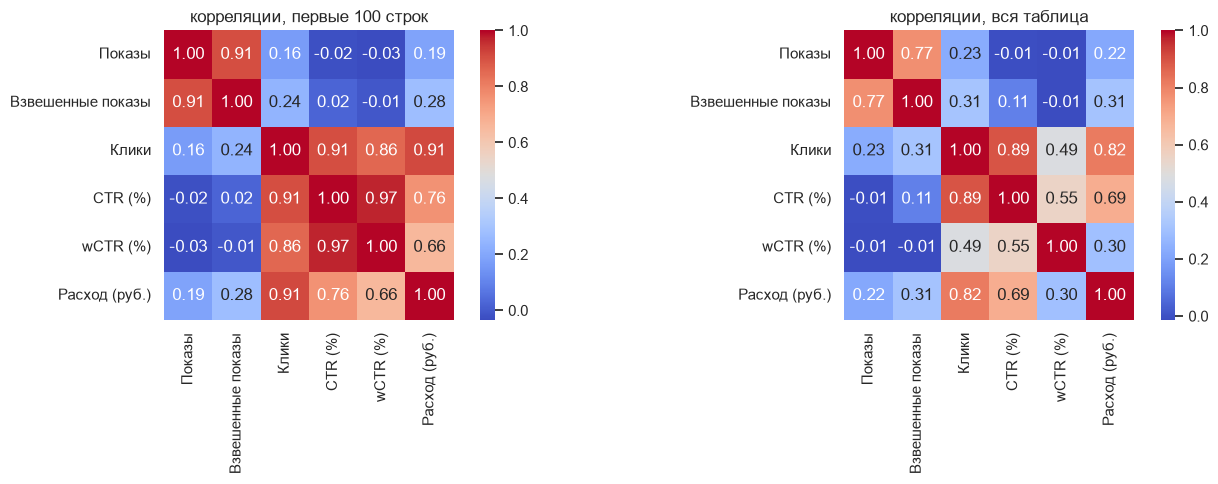

In [15]:
metrics = ["Показы", "Взвешенные показы", "Клики", "CTR (%)", "wCTR (%)", "Расход (руб.)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(data[metrics].head(100).corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0], square=True)
axes[0].set_title("корреляции, первые 100 строк")
sns.heatmap(data[metrics].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1], square=True)
axes[1].set_title("корреляции, вся таблица")
plt.tight_layout()
plt.show()


### Что из этого следует для цели

- Строку как объект модели можно оставить, но тогда цель «CTR в строке» — почти монетка 0/100.
- Честнее предсказывать клик при показе или долю кликов в сегменте (день, группа, объявление).
- Заказ в этой выгрузке не целевая колонка: её нет.
- Корзину имеет смысл смотреть только после укрупнения зерна, иначе 22 единицы на 10 тысяч строк.


### Вопросы

- Если собрать таблицу по объявлению и дню, какие колонки станут целью, какие — признаками?
- Где countplot врёт сильнее: возраст, группа или таргетинг?
- Почему wCTR на всей таблице почти не связан с CTR строки, а на первых 100 строках связан?
